<a href="https://colab.research.google.com/github/1Fahad-2/AI-in-Cybersecurity/blob/main/Spam_url_detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
df = pd.read_csv('/content/url_spam_classification.csv')

In [40]:
df.head()

,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,True
1,https://www.hvper.com/,True
2,https://briefingday.com/m/v4n3i4f3,True
3,https://briefingday.com/n/20200618/m#commentform,False
4,https://briefingday.com/fan,True


In [41]:
df.shape

(148303, 2)

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148303 entries, 0 to 148302
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   url      148303 non-null  object
 1   is_spam  148303 non-null  bool  
dtypes: bool(1), object(1)
memory usage: 1.3+ MB


In [43]:
df.isnull().sum()

,0
url,0
is_spam,0


In [44]:
df.is_spam.value_counts()

,count
is_spam,
False,101021
True,47282


In [45]:
df.dropna(subset=['is_spam'], inplace=True)

In [46]:
df = df[['url', 'is_spam']]
df.rename(columns={'is_spam': 'type'}, inplace=True)
df['type'] = df['type'].map({True: 'Spam', False: 'Not Spam'})
df.head()

,url,type
0,https://briefingday.us8.list-manage.com/unsubs...,Spam
1,https://www.hvper.com/,Spam
2,https://briefingday.com/m/v4n3i4f3,Spam
3,https://briefingday.com/n/20200618/m#commentform,Not Spam
4,https://briefingday.com/fan,Spam


In [47]:
from nltk.tokenize import RegexpTokenizer
tokenizer = RegexpTokenizer(r'[A-Za-z]+')

In [48]:
df.url[0]

'https://briefingday.us8.list-manage.com/unsubscribe'

In [49]:
tokenizer.tokenize(df.url[0])

['https', 'briefingday', 'us', 'list', 'manage', 'com', 'unsubscribe']

In [50]:
df['text_tokenized'] = df.url.map(lambda t: tokenizer.tokenize(t))
df.head()

,url,type,text_tokenized
0,https://briefingday.us8.list-manage.com/unsubs...,Spam,"[https, briefingday, us, list, manage, com, un..."
1,https://www.hvper.com/,Spam,"[https, www, hvper, com]"
2,https://briefingday.com/m/v4n3i4f3,Spam,"[https, briefingday, com, m, v, n, i, f]"
3,https://briefingday.com/n/20200618/m#commentform,Not Spam,"[https, briefingday, com, n, m, commentform]"
4,https://briefingday.com/fan,Spam,"[https, briefingday, com, fan]"


In [51]:
from nltk.stem.snowball import SnowballStemmer
stemmer = SnowballStemmer('english')
df['text_stemmed'] = df['text_tokenized'].map(lambda l: [stemmer.stem(word) for word in l])
df.head()

,url,type,text_tokenized,text_stemmed
0,https://briefingday.us8.list-manage.com/unsubs...,Spam,"[https, briefingday, us, list, manage, com, un...","[https, briefingday, us, list, manag, com, uns..."
1,https://www.hvper.com/,Spam,"[https, www, hvper, com]","[https, www, hvper, com]"
2,https://briefingday.com/m/v4n3i4f3,Spam,"[https, briefingday, com, m, v, n, i, f]","[https, briefingday, com, m, v, n, i, f]"
3,https://briefingday.com/n/20200618/m#commentform,Not Spam,"[https, briefingday, com, n, m, commentform]","[https, briefingday, com, n, m, commentform]"
4,https://briefingday.com/fan,Spam,"[https, briefingday, com, fan]","[https, briefingday, com, fan]"


In [52]:
df.tail()

,url,type,text_tokenized,text_stemmed
148298,"https://cdn.substack.com/image/fetch/f_auto,q_...",Spam,"[https, cdn, substack, com, image, fetch, f, a...","[https, cdn, substack, com, imag, fetch, f, au..."
148299,https://numlock.substack.com/subscribe,Spam,"[https, numlock, substack, com, subscribe]","[https, numlock, substack, com, subscrib]"
148300,https://docs.google.com/forms/d/e/1FAIpQLSfDLO...,Spam,"[https, docs, google, com, forms, d, e, FAIpQL...","[https, doc, googl, com, form, d, e, faipqlsfd..."
148301,https://bookclub.substack.com/,Spam,"[https, bookclub, substack, com]","[https, bookclub, substack, com]"
148302,https://awards.substack.com/,Spam,"[https, awards, substack, com]","[https, award, substack, com]"


In [53]:
df['text'] = df['text_stemmed'].map(lambda l: ' '.join(l))
df.dropna(subset=['type'], inplace=True)
df.head()

,url,type,text_tokenized,text_stemmed,text
0,https://briefingday.us8.list-manage.com/unsubs...,Spam,"[https, briefingday, us, list, manage, com, un...","[https, briefingday, us, list, manag, com, uns...",https briefingday us list manag com unsubscrib
1,https://www.hvper.com/,Spam,"[https, www, hvper, com]","[https, www, hvper, com]",https www hvper com
2,https://briefingday.com/m/v4n3i4f3,Spam,"[https, briefingday, com, m, v, n, i, f]","[https, briefingday, com, m, v, n, i, f]",https briefingday com m v n i f
3,https://briefingday.com/n/20200618/m#commentform,Not Spam,"[https, briefingday, com, n, m, commentform]","[https, briefingday, com, n, m, commentform]",https briefingday com n m commentform
4,https://briefingday.com/fan,Spam,"[https, briefingday, com, fan]","[https, briefingday, com, fan]",https briefingday com fan


In [54]:
Spam_sites = df[df.type == 'Spam']
Not_Spam_sites = df[df.type == 'Not Spam']
Spam_sites.head()

,url,type,text_tokenized,text_stemmed,text
0,https://briefingday.us8.list-manage.com/unsubs...,Spam,"[https, briefingday, us, list, manage, com, un...","[https, briefingday, us, list, manag, com, uns...",https briefingday us list manag com unsubscrib
1,https://www.hvper.com/,Spam,"[https, www, hvper, com]","[https, www, hvper, com]",https www hvper com
2,https://briefingday.com/m/v4n3i4f3,Spam,"[https, briefingday, com, m, v, n, i, f]","[https, briefingday, com, m, v, n, i, f]",https briefingday com m v n i f
4,https://briefingday.com/fan,Spam,"[https, briefingday, com, fan]","[https, briefingday, com, fan]",https briefingday com fan
29,https://join1440.com/,Spam,"[https, join, com]","[https, join, com]",https join com


In [55]:
Not_Spam_sites.head()

,url,type,text_tokenized,text_stemmed,text
3,https://briefingday.com/n/20200618/m#commentform,Not Spam,"[https, briefingday, com, n, m, commentform]","[https, briefingday, com, n, m, commentform]",https briefingday com n m commentform
5,https://www.brookings.edu/interactives/reopeni...,Not Spam,"[https, www, brookings, edu, interactives, reo...","[https, www, brook, edu, interact, reopen, ame...",https www brook edu interact reopen america an...
6,https://www.reuters.com/investigates/special-r...,Not Spam,"[https, www, reuters, com, investigates, speci...","[https, www, reuter, com, investig, special, r...",https www reuter com investig special report h...
7,https://www.theatlantic.com/magazine/archive/2...,Not Spam,"[https, www, theatlantic, com, magazine, archi...","[https, www, theatlant, com, magazin, archiv, ...",https www theatlant com magazin archiv superma...
8,https://www.vox.com/2020/6/17/21294680/john-bo...,Not Spam,"[https, www, vox, com, john, bolton, book, exc...","[https, www, vox, com, john, bolton, book, exc...",https www vox com john bolton book excerpt tru...


### Word Cloud Generation

To visualize the most frequent words, a word cloud can be a helpful tool. We'll generate separate word clouds for 'Spam' and 'Not Spam' URLs to see if there are any distinct patterns.

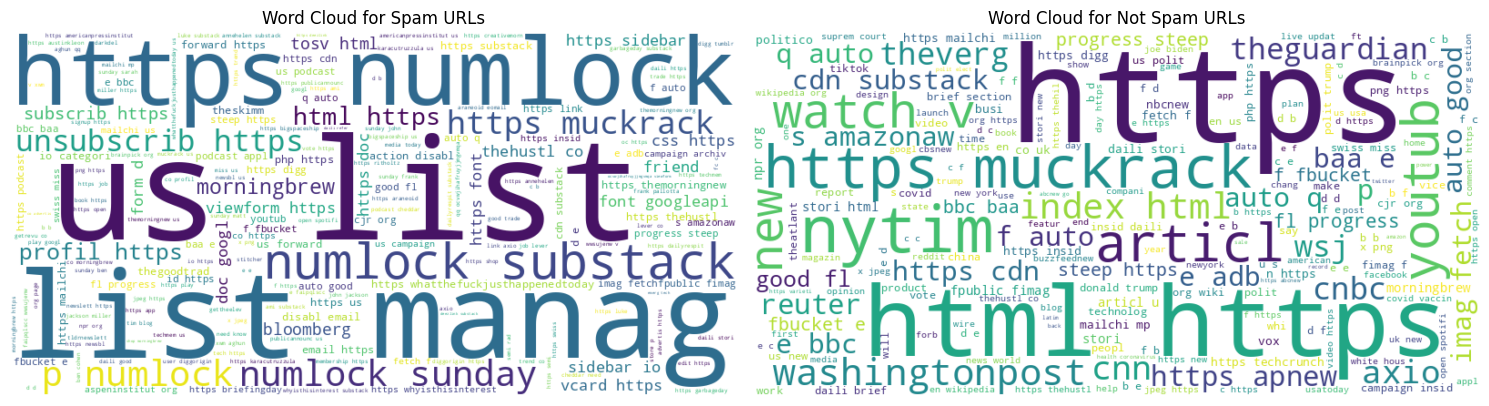

'https briefingday com n m commentform https www brook edu interact reopen america and the world https www reuter com investig special report health coronavirus britain pub https www theatlant com magazin archiv supermarket are a miracl https www vox com john bolton book excerpt trump ukrain china https www theguardian com travel jun end of tourism coronavirus pandem travel industri https www bbc com futur articl what if all virus disappear https narrat com the quarantin hippi trap in a jungl paradis https ourworldindata org grapher daili covid case day averag https www spike onlin com a healthi societi doe not destroy it monument https www nytim com interact busi economi how contain ship are built html https aeon co essay nostalgia is the rocket fuel that power hope and chang https www youtub com watch v k wcu agyz ref briefingday com curat briefingday com utm sourc briefingday com utm medium email https www popsci com stori scienc haribo gummi candi flavor https www atlasobscura com 

In [56]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all text for Spam URLs
spam_text = ' '.join(Spam_sites['text'])

# Combine all text for Not Spam URLs
not_spam_text = ' '.join(Not_Spam_sites['text'])

# Generate word cloud for Spam URLs
spam_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(spam_text)

# Generate word cloud for Not Spam URLs
not_spam_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(not_spam_text)

# Display the word clouds
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(spam_wordcloud, interpolation='bilinear')
plt.title('Word Cloud for Spam URLs')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(not_spam_wordcloud, interpolation='bilinear')
plt.title('Word Cloud for Not Spam URLs')
plt.axis('off')

plt.tight_layout()
plt.show()

all_text = ' '.join(Not_Spam_sites['text'].tolist())
all_text

In [57]:
all_text = ' '.join(Spam_sites['text'].tolist())
all_text

'https briefingday us list manag com unsubscrib https www hvper com https briefingday com m v n i f https briefingday com fan https join com https link morningbrew com manag z oc https austinkleon us list manag com subscrib confirm https ourworldindata org grapher daili covid death day averag https briefingday us list manag com unsubscrib https www hvper com https briefingday com m v n i f https briefingday com fan https doc googl com form d e faipqlsew gtg klzyheqk kpsx grsgsosa xgsr rm lrzyduqbw viewform https stackmedia io https doc googl com form d e faipqlscc wwsujenw v xwm aghun qq ocvwjihafruyjjmgvmqa viewform https www businesscasu fm https www morningbrew com emerg tech https www morningbrew com retail https www morningbrew com daili stori covid consum https www morningbrew com https briefingday com fan https briefingday com m v n i f https www hvper com https briefingday us list manag com unsubscrib https www bloomberg com tosv html https www morningbrew com privaci https lin

In [58]:
from wordcloud import WordCloud

In [59]:
!pip install WordCloud

In [60]:
df.head()

,url,type,text_tokenized,text_stemmed,text
0,https://briefingday.us8.list-manage.com/unsubs...,Spam,"[https, briefingday, us, list, manage, com, un...","[https, briefingday, us, list, manag, com, uns...",https briefingday us list manag com unsubscrib
1,https://www.hvper.com/,Spam,"[https, www, hvper, com]","[https, www, hvper, com]",https www hvper com
2,https://briefingday.com/m/v4n3i4f3,Spam,"[https, briefingday, com, m, v, n, i, f]","[https, briefingday, com, m, v, n, i, f]",https briefingday com m v n i f
3,https://briefingday.com/n/20200618/m#commentform,Not Spam,"[https, briefingday, com, n, m, commentform]","[https, briefingday, com, n, m, commentform]",https briefingday com n m commentform
4,https://briefingday.com/fan,Spam,"[https, briefingday, com, fan]","[https, briefingday, com, fan]",https briefingday com fan


In [61]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()
features = vectorizer.fit_transform(df.text)
features[:5].toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [62]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(features, df.type)

In [63]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [64]:
model.score(x_test, y_test)*100

95.4310065810767

In [65]:
model.score(x_train,y_train)*100

96.88115295746536

In [66]:
from sklearn.metrics import classification_report
y_pred = model.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Not Spam       0.96      0.97      0.97     25351
        Spam       0.93      0.92      0.93     11725

    accuracy                           0.95     37076
   macro avg       0.95      0.95      0.95     37076
weighted avg       0.95      0.95      0.95     37076



In [67]:
from sklearn.metrics import confusion_matrix
con_mat = pd.DataFrame(confusion_matrix(model.predict(x_test), y_test),
                       columns = ['Predicted:Not Spam', 'Predicted:Spam'],
                       index = ['Actual:Not Spam', 'Actual:Spam'])
con_mat

,Predicted:Not Spam,Predicted:Spam
Actual:Not Spam,24554,897
Actual:Spam,797,10828


In [68]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(x_train, y_train)

MultinomialNB()

In [69]:
model.score(x_test, y_test)*100

89.0279426043802

In [70]:
model.score(x_train,y_train)*100

90.79540039738554

In [75]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(x_train, y_train)

RandomForestClassifier()

In [76]:
model.score(x_test, y_test)*100

97.04660696946812

In [77]:
model.score(x_train,y_train)*100

99.68802538951873

In [78]:
from sklearn.svm import SVC
model = SVC()
model.fit(x_train, y_train)

SVC()

In [79]:
model.score(x_test, y_test)*100

96.79307368648182

In [80]:
model.score(x_train,y_train)*100

97.67682307353431